In [3]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.models import resnet50
import pandas as pd
import scripts.train as train
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_curve, average_precision_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
model = resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load('model/model.pt', map_location=device))
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
losses = pd.read_csv('model/losses.csv', index_col=0)
metrics = pd.read_csv('model/metrics.csv', index_col=0)

losses.index.name = 'epoch'
metrics.index.name = 'epoch'

In [6]:
losses

,train,val
epoch,,
0,0.284307,0.255882
1,0.154644,0.186018
2,0.112573,0.226908
3,0.076907,0.311318
4,0.113658,0.134014
5,0.076033,0.284325
6,0.082732,0.250919
7,0.065602,0.096457
8,0.046868,0.110548


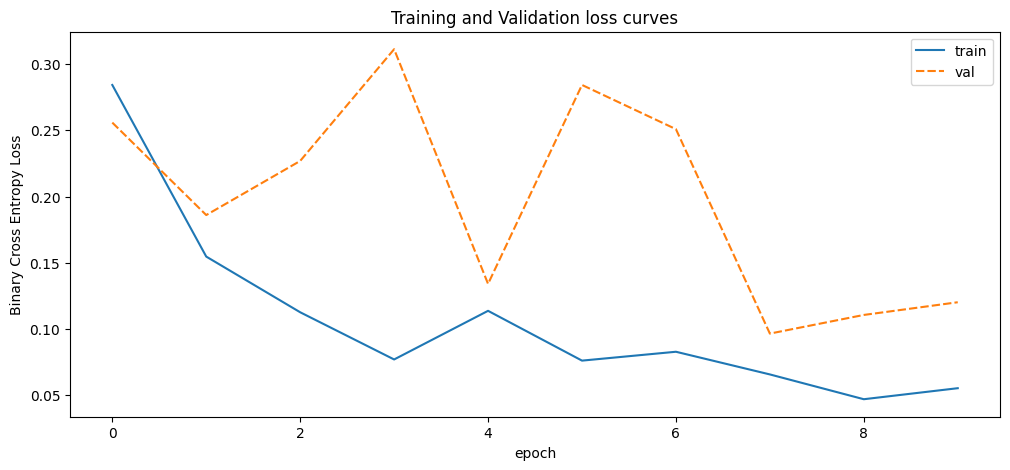

In [7]:
plt.figure(figsize=(12, 5))
plt.title('Training and Validation loss curves')
sns.lineplot(data=losses)
plt.ylabel('Binary Cross Entropy Loss')
plt.show()

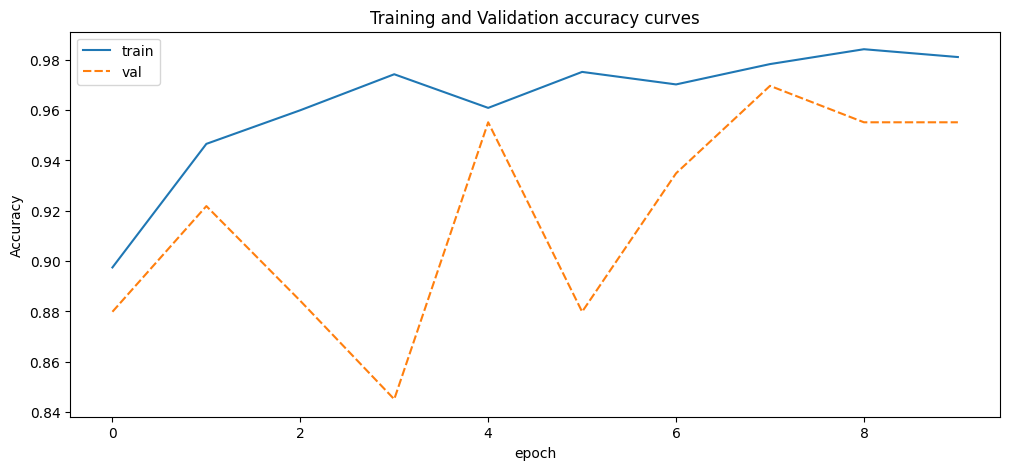

In [8]:
plt.figure(figsize=(12, 5))
plt.title('Training and Validation accuracy curves')
sns.lineplot(data=metrics)
plt.ylabel('Accuracy')
plt.show()

Although the model's loss and accuracy moves quite sharply - and may benefit from more epochs and a lower learning rate, the validation loss and accuracies reached are very good.

In [9]:
_, test_transform = train.set_transforms()
test_dataset = train.make_dataset(set='test', transforms=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [10]:
test_dataset

Dataset ImageFolder
    Number of datapoints: 690
    Root location: data/test
    StandardTransform
Transform: Compose(
                 ToImage()
                 Grayscale(num_output_channels=3)
                 Resize(size=[224], interpolation=InterpolationMode.BILINEAR, antialias=True)
                 CenterCrop(size=(224, 224))
                 ToDtype(scale=True)
                 Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
           )

In [11]:
labels = []
predictions = []

In [12]:
model.eval()
for batch_X, batch_y in test_loader:
    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)

    with torch.no_grad():
        outputs = model.forward(batch_X)
        preds = torch.sigmoid(outputs)
    labels.append(batch_y.cpu())
    predictions.append(preds.cpu())

In [13]:
predictions = torch.vstack(predictions).numpy()
labels = torch.hstack(labels).numpy()

In [14]:
precision, recall, thresholds = precision_recall_curve(labels, predictions)

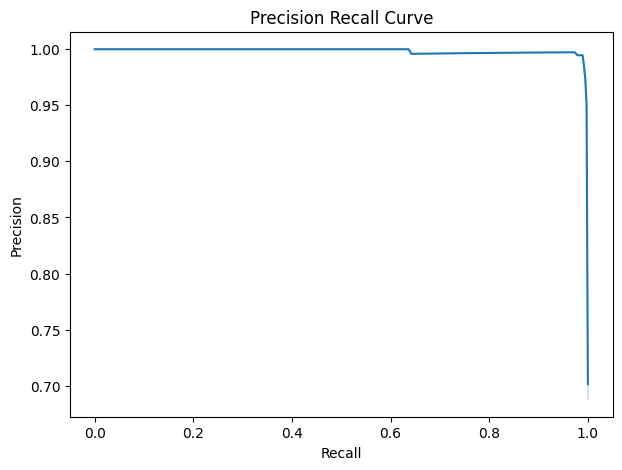

In [15]:
plt.figure(figsize=(7, 5))
sns.lineplot(x=recall, y=precision)
plt.title('Precision Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [16]:
average_precision = average_precision_score(labels, predictions)

average_precision

0.9984767786202117

The precision recall curve and average precision score shows that the model is performing very well.